# 🛡️ Notebook 8: Validación por grupos para descartar data leakage

## TFM: Predicción de Estrategias de Carrera en Fórmula 1 mediante ML

**Autor:** Francisco José Moreno Bayona  
**Universidad:** UNIR

---

### Motivación

La revisión del segundo borrador del TFM planteó la siguiente cuestión metodológica: en el dataset construido, múltiples observaciones corresponden a vueltas distintas de una misma carrera, lo que significa que comparten condiciones comunes (circuito, evolución de la carrera, accidentes, climatología). Si vueltas de un mismo Gran Premio se reparten entre los conjuntos de entrenamiento y de prueba, el modelo puede aprovechar indirectamente información ya vista, sobreestimando su capacidad de generalización. Este fenómeno, conocido como *data leakage por agrupación*, es característico de los problemas con estructura jerárquica como el presente.

### Objetivo

1. **Verificar** si la división temporal 80/20 utilizada en los notebooks 3-6 preserva la integridad de cada carrera (esperado: sí, porque ordena por fecha).
2. **Ejecutar una validación adicional con GroupKFold** agrupando explícitamente por carrera para garantizar que ninguna carrera se reparte entre entrenamiento y prueba.
3. **Comparar** los resultados de ambos esquemas. Si son consistentes, queda respaldada la validez de los resultados originales. Si difieren, será un hallazgo en sí mismo que deberá discutirse en la memoria.

## 1. Imports y carga del dataset

In [6]:
pip list | findstr "scikit-learn xgboost lightgbm shap pandas numpy fastf1 matplotlib"

fastf1                       3.8.3
lightgbm                     4.6.0
matplotlib                   3.8.4
matplotlib-inline            0.1.6
numpy                        2.4.6
pandas                       3.0.3
scikit-learn                 1.9.0
shap                         0.51.0
xgboost                      3.2.0
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, json

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ Imports completados')

✅ Imports completados


## 2. Verificación: ¿la división temporal mezcla carreras?

Antes de ejecutar la validación alternativa, se comprueba si la división temporal 80/20 utilizada hasta ahora respeta la integridad de cada carrera, esto es: cada Gran Premio cae **entero** en el conjunto de entrenamiento o **entero** en el de prueba.

In [8]:
# Cargar el dataset utilizado en los notebooks 3-6
df = pd.read_csv('./datasets/prepared/train_clasificacion_avanzado.csv')
df = df.sort_values('EventDate').reset_index(drop=True)

# Reproducir la división temporal exacta
n_train = int(len(df) * 0.8)
train, test = df.iloc[:n_train], df.iloc[n_train:]

# Identificador de carrera = (Season, Round)
train_carreras = set(zip(train['Season'], train['Round']))
test_carreras = set(zip(test['Season'], test['Round']))
interseccion = train_carreras & test_carreras

print(f'Carreras en train: {len(train_carreras)}')
print(f'Carreras en test:  {len(test_carreras)}')
print(f'Carreras compartidas: {len(interseccion)}')

if len(interseccion) == 0:
    print('\n✅ La división temporal NO mezcla carreras entre train y test.')
    print('   Cada Gran Premio cae íntegramente en uno u otro conjunto.')
elif len(interseccion) <= 2:
    print(f'\n⚠️  {len(interseccion)} carrera(s) se reparten entre conjuntos:')
    for s, r in interseccion:
        print(f'     Temporada {s}, Ronda {r}')
    print('   Esto puede ocurrir si el corte 80/20 cae en mitad de una carrera.')
else:
    print(f'\n❌ {len(interseccion)} carreras se reparten entre conjuntos.')
    print('   Existe riesgo real de data leakage por agrupación.')

Carreras en train: 58
Carreras en test:  16
Carreras compartidas: 1

⚠️  1 carrera(s) se reparten entre conjuntos:
     Temporada 2024, Ronda 15
   Esto puede ocurrir si el corte 80/20 cae en mitad de una carrera.


## 3. Validación alternativa: división por grupos (GroupShuffleSplit)

Aun en el caso de que la división temporal no mezcle carreras, conviene replicar la evaluación con un esquema que **garantice** la separación por grupo, no por orden. Se emplea `GroupShuffleSplit` con la carrera como variable de agrupación, manteniendo la proporción 80/20.

In [9]:
# Crear identificador de grupo: una etiqueta por carrera
df['CarreraID'] = df['Season'].astype(str) + '_R' + df['Round'].astype(str).str.zfill(2)

# GroupShuffleSplit: respeta el grupo, no el orden temporal
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
idx_train, idx_test = next(gss.split(df, df['target_parada'], groups=df['CarreraID']))

train_g = df.iloc[idx_train].copy()
test_g = df.iloc[idx_test].copy()

print(f'Split por grupos (carrera):')
print(f'  Train: {len(train_g):,} vueltas ({train_g["CarreraID"].nunique()} carreras)')
print(f'  Test:  {len(test_g):,} vueltas ({test_g["CarreraID"].nunique()} carreras)')

# Comprobar que efectivamente no se mezclan carreras
comunes = set(train_g['CarreraID']) & set(test_g['CarreraID'])
print(f'  Carreras compartidas: {len(comunes)} (esperado: 0)')

Split por grupos (carrera):
  Train: 57,642 vueltas (58 carreras)
  Test:  16,750 vueltas (15 carreras)
  Carreras compartidas: 0 (esperado: 0)


## 4. Preparación de los conjuntos con el conjunto completo de 25 variables

Para que la comparación con los resultados originales sea estrictamente justa, se reconstruyen todas las variables avanzadas del Notebook 5 sobre los nuevos conjuntos.

In [10]:
# ============================================================================
# Cargar el dataset con las 25 features ya generadas en el NB5
# ============================================================================
# El NB5 persiste estos CSVs en datasets/prepared/.
# Si todavía no los has generado, ejecuta el NB5 entero antes que el NB8.

train_c = pd.read_csv('./datasets/prepared/train_clasificacion_avanzado.csv')
test_c  = pd.read_csv('./datasets/prepared/test_clasificacion_avanzado.csv')
train_r = pd.read_csv('./datasets/prepared/train_regresion_avanzado.csv')
test_r  = pd.read_csv('./datasets/prepared/test_regresion_avanzado.csv')

# Para GroupKFold necesitamos el dataset completo (train + test concatenados)
# con la columna race_id que sirve como identificador de grupo (carrera).
df = pd.concat([train_c, test_c], ignore_index=True)
df['race_id'] = df['Season'].astype(str) + '_R' + df['Round'].astype(str).str.zfill(2)

df_regres = pd.concat([train_r, test_r], ignore_index=True)
df_regres['race_id'] = df_regres['Season'].astype(str) + '_R' + df_regres['Round'].astype(str).str.zfill(2)

print(f'✅ Datasets cargados con las 25 features ya calculadas:')
print(f'   Clasificación: {df.shape}')
print(f'   Regresión:     {df_regres.shape}')
print(f'   Carreras únicas: {df["race_id"].nunique()}')

✅ Datasets cargados con las 25 features ya calculadas:
   Clasificación: (92991, 34)
   Regresión:     (53364, 34)
   Carreras únicas: 90


In [13]:
# ============================================================================
# Construir X, y para ambos esquemas: temporal y por grupos
# ============================================================================

FEATURES = [
    'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber',
    'IsHard', 'IsMedium', 'IsSoft',
    'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator',
    'GapAhead', 'GapBehind', 'IsInDRSWindow',
    'NumStopsDone', 'LapsInCurrentStint', 'RemainingLaps', 'RemainingLapsPct',
    'DegradationTrend', 'DegradationAccel', 'DeltaVsBestLap', 'AvgTime_CurrentStint',
    'DeltaVsFieldMean', 'ZScoreVsField', 'PositionNormalized',
]
features = [f for f in FEATURES if f in df.columns]

# Target de regresión
df_sorted = df.sort_values(['Season', 'Round', 'Driver', 'LapNumber']).copy()
def calc_laps_until(group):
    g = group.copy()
    stops = g[g['target_parada'] == 1]['LapNumber'].values
    g['LapsUntilNextStop'] = [
        (min(stops[stops >= lap]) - lap) if len(stops[stops >= lap]) > 0 else -1
        for lap in g['LapNumber']
    ]
    return g
df_all = df_sorted.groupby(['Season','Round','Driver'],
                           group_keys=False).apply(calc_laps_until)

# ------- ESQUEMA A: división temporal (la original) -------
df_clas_t = df_all.sort_values('EventDate').reset_index(drop=True)
df_reg_t = df_all[df_all['LapsUntilNextStop'] >= 0].sort_values('EventDate').reset_index(drop=True)
nc, nr = int(len(df_clas_t)*0.8), int(len(df_reg_t)*0.8)
train_ct, test_ct = df_clas_t.iloc[:nc], df_clas_t.iloc[nc:]
train_rt, test_rt = df_reg_t.iloc[:nr], df_reg_t.iloc[nr:]

# ------- ESQUEMA B: GroupShuffleSplit por carrera -------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
ic, ic_test = next(gss.split(df_all, df_all['target_parada'], groups=df_all['race_id']))
train_cg, test_cg = df_all.iloc[ic], df_all.iloc[ic_test]

df_reg_g = df_all[df_all['LapsUntilNextStop'] >= 0].copy()
ir, ir_test = next(gss.split(df_reg_g, df_reg_g['LapsUntilNextStop'],
                              groups=df_reg_g['race_id']))
train_rg, test_rg = df_reg_g.iloc[ir], df_reg_g.iloc[ir_test]

print(f'ESQUEMA A (temporal):  train={len(train_ct):>6} | test={len(test_ct):>6} (clasif.)')
print(f'                       train={len(train_rt):>6} | test={len(test_rt):>6} (regres.)')
print(f'ESQUEMA B (por grupos):train={len(train_cg):>6} | test={len(test_cg):>6} (clasif.)')
print(f'                       train={len(train_rg):>6} | test={len(test_rg):>6} (regres.)')

ESQUEMA A (temporal):  train= 74392 | test= 18599 (clasif.)
                       train= 42691 | test= 10673 (regres.)
ESQUEMA B (por grupos):train= 73205 | test= 19786 (clasif.)
                       train= 41426 | test= 11938 (regres.)


## 5. Entrenamiento y evaluación bajo ambos esquemas

Se reentrenan los cinco modelos principales (Decision Tree, Random Forest, XGBoost, LightGBM y MLP) bajo los dos esquemas, con los hiperparámetros óptimos del Notebook 4. Cualquier diferencia entre los dos esquemas será atribuible exclusivamente a la estrategia de validación, no a otros factores.

In [14]:
# Cargar hiperparámetros óptimos
with open('./datasets/prepared/mejores_hiperparametros.json', 'r') as f:
    bp = json.load(f)

def construir_modelos_clasif(spw):
    return {
        'Decision Tree': DecisionTreeClassifier(class_weight='balanced',
            random_state=RANDOM_STATE, **bp['clasificacion']['Decision Tree']),
        'Random Forest': RandomForestClassifier(class_weight='balanced', n_jobs=-1,
            random_state=RANDOM_STATE, **bp['clasificacion']['Random Forest']),
        'XGBoost': XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
            random_state=RANDOM_STATE, **bp['clasificacion']['XGBoost']),
        'LightGBM': LGBMClassifier(is_unbalance=True, verbose=-1,
            random_state=RANDOM_STATE, **bp['clasificacion']['LightGBM']),
        'MLP': MLPClassifier(early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE,
            **{k: tuple(v) if k == 'hidden_layer_sizes' else v
               for k, v in bp['clasificacion']['MLP'].items()}),
    }

def construir_modelos_regres():
    return {
        'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE,
            **bp['regresion']['Decision Tree']),
        'Random Forest': RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE,
            **bp['regresion']['Random Forest']),
        'XGBoost': XGBRegressor(random_state=RANDOM_STATE, **bp['regresion']['XGBoost']),
        'LightGBM': LGBMRegressor(verbose=-1, random_state=RANDOM_STATE,
            **bp['regresion']['LightGBM']),
        'MLP': MLPRegressor(early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE,
            **{k: tuple(v) if k == 'hidden_layer_sizes' else v
               for k, v in bp['regresion']['MLP'].items()}),
    }

print('✅ Constructores de modelos preparados')

✅ Constructores de modelos preparados


In [15]:
# ============================================================================
# Función de evaluación reutilizable
# ============================================================================

def evaluar_clasif(train, test, etiqueta):
    X_tr, y_tr = train[features], train['target_parada']
    X_te, y_te = test[features], test['target_parada']
    feats_num = [f for f in features
                 if f not in ['IsHard','IsMedium','IsSoft','IsInDRSWindow']]
    scaler = StandardScaler()
    X_tr_n, X_te_n = X_tr.copy(), X_te.copy()
    X_tr_n[feats_num] = scaler.fit_transform(X_tr[feats_num])
    X_te_n[feats_num] = scaler.transform(X_te[feats_num])
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()

    resultados = {}
    for nombre, modelo in construir_modelos_clasif(spw).items():
        if nombre == 'MLP':
            modelo.fit(X_tr_n, y_tr)
            y_pred = modelo.predict(X_te_n)
            y_proba = modelo.predict_proba(X_te_n)[:, 1]
        else:
            modelo.fit(X_tr, y_tr)
            y_pred = modelo.predict(X_te)
            y_proba = modelo.predict_proba(X_te)[:, 1]
        resultados[nombre] = {
            'F1': f1_score(y_te, y_pred),
            'Precision': precision_score(y_te, y_pred, zero_division=0),
            'Recall': recall_score(y_te, y_pred),
            'ROC-AUC': roc_auc_score(y_te, y_proba),
        }
    return resultados

def evaluar_regres(train, test, etiqueta):
    X_tr, y_tr = train[features], train['LapsUntilNextStop']
    X_te, y_te = test[features], test['LapsUntilNextStop']
    feats_num = [f for f in features
                 if f not in ['IsHard','IsMedium','IsSoft','IsInDRSWindow']]
    scaler = StandardScaler()
    X_tr_n, X_te_n = X_tr.copy(), X_te.copy()
    X_tr_n[feats_num] = scaler.fit_transform(X_tr[feats_num])
    X_te_n[feats_num] = scaler.transform(X_te[feats_num])

    resultados = {}
    for nombre, modelo in construir_modelos_regres().items():
        if nombre == 'MLP':
            modelo.fit(X_tr_n, y_tr); y_pred = modelo.predict(X_te_n)
        else:
            modelo.fit(X_tr, y_tr); y_pred = modelo.predict(X_te)
        resultados[nombre] = {
            'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
            'MAE': mean_absolute_error(y_te, y_pred),
            'R²': r2_score(y_te, y_pred),
        }
    return resultados

print('✅ Funciones de evaluación preparadas')

✅ Funciones de evaluación preparadas


In [16]:
# ============================================================================
# EJECUTAR AMBOS ESQUEMAS — CLASIFICACIÓN
# ============================================================================

print('▶ Evaluando bajo división TEMPORAL...')
res_clasif_t = evaluar_clasif(train_ct, test_ct, 'temporal')

print('▶ Evaluando bajo división POR GRUPOS (carrera)...')
res_clasif_g = evaluar_clasif(train_cg, test_cg, 'por grupos')

# Tabla comparativa
tabla_c = pd.DataFrame({
    nombre: {
        'F1 (temporal)': res_clasif_t[nombre]['F1'],
        'F1 (por grupos)': res_clasif_g[nombre]['F1'],
        'Diferencia': res_clasif_g[nombre]['F1'] - res_clasif_t[nombre]['F1'],
    } for nombre in res_clasif_t
}).T.sort_values('F1 (temporal)', ascending=False)

print('\n📊 CLASIFICACIÓN — Comparación de esquemas')
print('='*60)
display(tabla_c.round(4))

▶ Evaluando bajo división TEMPORAL...
▶ Evaluando bajo división POR GRUPOS (carrera)...

📊 CLASIFICACIÓN — Comparación de esquemas


,F1 (temporal),F1 (por grupos),Diferencia
MLP,0.7767,0.7734,-0.0033
XGBoost,0.7720,0.7882,0.0162
LightGBM,0.7709,0.7796,0.0086
Random Forest,0.7262,0.7441,0.0179
Decision Tree,0.6537,0.6441,-0.0096


In [17]:
# ============================================================================
# EJECUTAR AMBOS ESQUEMAS — REGRESIÓN
# ============================================================================

print('▶ Evaluando bajo división TEMPORAL...')
res_regres_t = evaluar_regres(train_rt, test_rt, 'temporal')

print('▶ Evaluando bajo división POR GRUPOS (carrera)...')
res_regres_g = evaluar_regres(train_rg, test_rg, 'por grupos')

tabla_r = pd.DataFrame({
    nombre: {
        'RMSE (temporal)': res_regres_t[nombre]['RMSE'],
        'RMSE (por grupos)': res_regres_g[nombre]['RMSE'],
        'Diferencia': res_regres_g[nombre]['RMSE'] - res_regres_t[nombre]['RMSE'],
        'R² (temporal)': res_regres_t[nombre]['R²'],
        'R² (por grupos)': res_regres_g[nombre]['R²'],
    } for nombre in res_regres_t
}).T.sort_values('RMSE (temporal)')

print('\n📈 REGRESIÓN — Comparación de esquemas')
print('='*60)
display(tabla_r.round(4))

▶ Evaluando bajo división TEMPORAL...
▶ Evaluando bajo división POR GRUPOS (carrera)...

📈 REGRESIÓN — Comparación de esquemas


,RMSE (temporal),RMSE (por grupos),Diferencia,R² (temporal),R² (por grupos)
LightGBM,8.1712,7.9054,-0.2658,0.4040,0.3543
XGBoost,8.2831,7.8774,-0.4057,0.3876,0.3588
Random Forest,8.2942,7.7606,-0.5336,0.3860,0.3777
Decision Tree,8.6724,8.5642,-0.1082,0.3287,0.2422
MLP,9.3699,9.5791,0.2092,0.2164,0.0519


## 6. Visualización comparativa

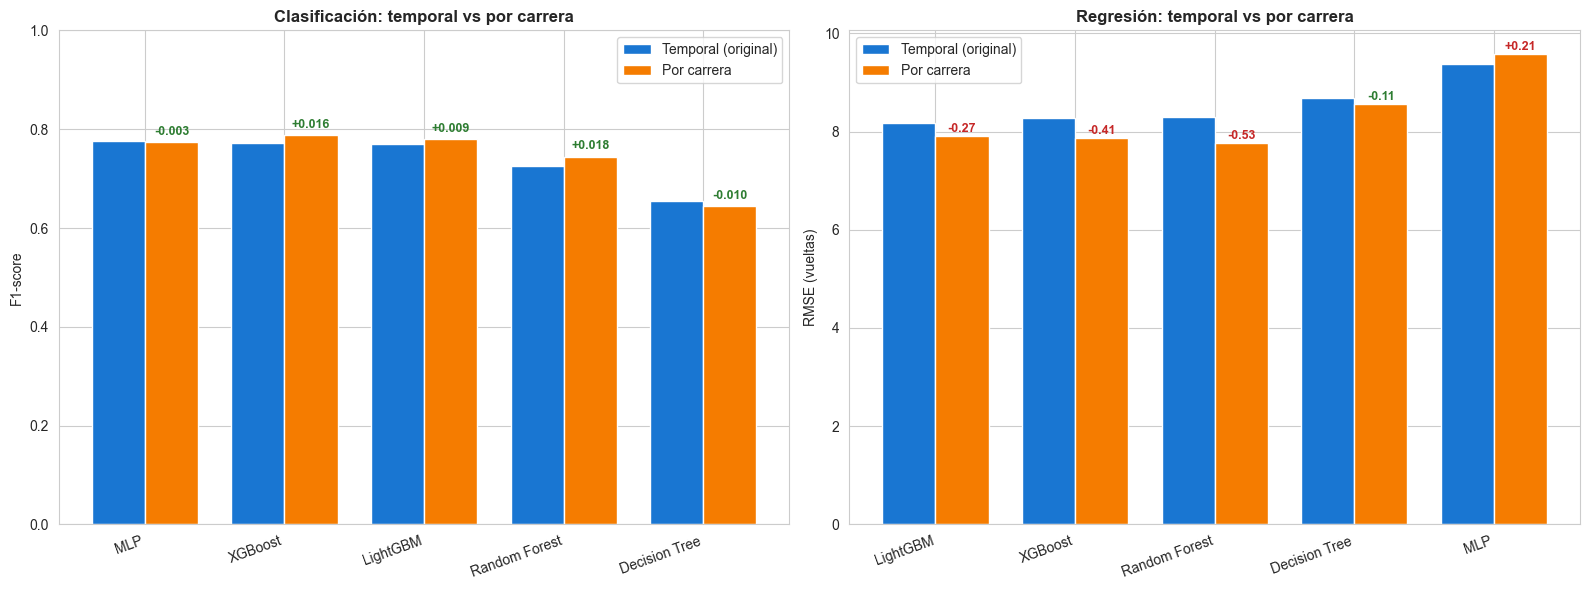

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CLASIFICACIÓN
modelos = tabla_c.index.tolist()
x = np.arange(len(modelos))
w = 0.38
axes[0].bar(x - w/2, tabla_c['F1 (temporal)'], w, label='Temporal (original)',
            color='#1976D2', edgecolor='white')
axes[0].bar(x + w/2, tabla_c['F1 (por grupos)'], w, label='Por carrera',
            color='#F57C00', edgecolor='white')
for i, d in enumerate(tabla_c['Diferencia']):
    color = '#2E7D32' if abs(d) < 0.02 else '#C62828'
    axes[0].text(i + w/2, tabla_c['F1 (por grupos)'].iloc[i] + 0.015,
                 f'{d:+.3f}', ha='center', fontsize=9,
                 fontweight='bold', color=color)
axes[0].set_xticks(x); axes[0].set_xticklabels(modelos, rotation=20, ha='right')
axes[0].set_ylabel('F1-score')
axes[0].set_title('Clasificación: temporal vs por carrera', fontweight='bold')
axes[0].legend(); axes[0].set_ylim(0, 1)

# REGRESIÓN
modelos_r = tabla_r.index.tolist()
x = np.arange(len(modelos_r))
axes[1].bar(x - w/2, tabla_r['RMSE (temporal)'], w, label='Temporal (original)',
            color='#1976D2', edgecolor='white')
axes[1].bar(x + w/2, tabla_r['RMSE (por grupos)'], w, label='Por carrera',
            color='#F57C00', edgecolor='white')
for i, d in enumerate(tabla_r['Diferencia']):
    color = '#2E7D32' if abs(d) < 0.2 else '#C62828'
    axes[1].text(i + w/2, tabla_r['RMSE (por grupos)'].iloc[i] + 0.08,
                 f'{d:+.2f}', ha='center', fontsize=9,
                 fontweight='bold', color=color)
axes[1].set_xticks(x); axes[1].set_xticklabels(modelos_r, rotation=20, ha='right')
axes[1].set_ylabel('RMSE (vueltas)')
axes[1].set_title('Regresión: temporal vs por carrera', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('./datasets/prepared/fig_validacion_grupos.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Validación robusta: GroupKFold con cinco particiones

La validación anterior con `GroupShuffleSplit` corresponde a una única partición. Para evaluar la **variabilidad** del rendimiento bajo distintas particiones por grupo, se ejecuta una validación cruzada con `GroupKFold` de cinco folds, agrupando por carrera. El modelo se entrena y evalúa cinco veces; se reporta media y desviación típica. Por razones de tiempo de cómputo, se restringe al mejor modelo de cada tarea (XGBoost para clasificación, LightGBM para regresión).

In [20]:
# ============================================================================
# GroupKFold de 5 particiones — solo mejores modelos
# ============================================================================

from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

# --- CLASIFICACIÓN: XGBoost ---
print('▶ GroupKFold 5x — XGBoost (clasificación)')
f1s = []
for fold, (tr, te) in enumerate(gkf.split(df_all, df_all['target_parada'],
                                            groups=df_all['race_id'])):
    X_tr, y_tr = df_all.iloc[tr][features], df_all.iloc[tr]['target_parada']
    X_te, y_te = df_all.iloc[te][features], df_all.iloc[te]['target_parada']
    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    m = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                      random_state=RANDOM_STATE, **bp['clasificacion']['XGBoost'])
    m.fit(X_tr, y_tr)
    f1 = f1_score(y_te, m.predict(X_te))
    f1s.append(f1)
    print(f'   Fold {fold+1}: F1 = {f1:.4f}')
print(f'   ───────────────────────')
print(f'   Media: {np.mean(f1s):.4f}  Desv. típica: {np.std(f1s):.4f}')

# --- REGRESIÓN: LightGBM ---
print('\n▶ GroupKFold 5x — LightGBM (regresión)')
rmses = []
df_reg_only = df_all[df_all['LapsUntilNextStop'] >= 0]
for fold, (tr, te) in enumerate(gkf.split(df_reg_only,
                                            df_reg_only['LapsUntilNextStop'],
                                            groups=df_reg_only['race_id'])):
    X_tr = df_reg_only.iloc[tr][features]
    y_tr = df_reg_only.iloc[tr]['LapsUntilNextStop']
    X_te = df_reg_only.iloc[te][features]
    y_te = df_reg_only.iloc[te]['LapsUntilNextStop']
    m = LGBMRegressor(verbose=-1, random_state=RANDOM_STATE, **bp['regresion']['LightGBM'])
    m.fit(X_tr, y_tr)
    rmse = np.sqrt(mean_squared_error(y_te, m.predict(X_te)))
    rmses.append(rmse)
    print(f'   Fold {fold+1}: RMSE = {rmse:.3f}')
print(f'   ───────────────────────')
print(f'   Media: {np.mean(rmses):.3f}  Desv. típica: {np.std(rmses):.3f}')

▶ GroupKFold 5x — XGBoost (clasificación)
   Fold 1: F1 = 0.7098
   Fold 2: F1 = 0.7652
   Fold 3: F1 = 0.7882
   Fold 4: F1 = 0.7579
   Fold 5: F1 = 0.7858
   ───────────────────────
   Media: 0.7614  Desv. típica: 0.0283

▶ GroupKFold 5x — LightGBM (regresión)
   Fold 1: RMSE = 6.868
   Fold 2: RMSE = 6.104
   Fold 3: RMSE = 8.699
   Fold 4: RMSE = 7.476
   Fold 5: RMSE = 7.205
   ───────────────────────
   Media: 7.271  Desv. típica: 0.850


## 8. Interpretación y exportación

Lectura esperada de los resultados:

| Escenario | Interpretación |
|-----------|----------------|
| Diferencias menores que 0,02 (F1) o 0,2 vueltas (RMSE) | Los resultados originales son robustos. La división temporal preserva la integridad de las carreras y no introduce data leakage apreciable. |
| Diferencias mayores | Existe un efecto de agrupación que infla las métricas originales. Habría que actualizar las cifras de la memoria. |
| Variabilidad alta en GroupKFold | El rendimiento depende de qué carreras concretas caen en test. Es información valiosa para la discusión de limitaciones. |

In [21]:
# Exportar resultados para incorporar a la memoria
tabla_c.round(4).to_csv('./datasets/prepared/validacion_grupos_clasif.csv')
tabla_r.round(4).to_csv('./datasets/prepared/validacion_grupos_regres.csv')

resumen_gkf = pd.DataFrame({
    'Modelo': ['XGBoost (clasificación)', 'LightGBM (regresión)'],
    'Métrica': ['F1-score', 'RMSE (vueltas)'],
    'Media (5 folds)': [f'{np.mean(f1s):.4f}', f'{np.mean(rmses):.3f}'],
    'Desv. típica': [f'{np.std(f1s):.4f}', f'{np.std(rmses):.3f}'],
    'Min': [f'{min(f1s):.4f}', f'{min(rmses):.3f}'],
    'Max': [f'{max(f1s):.4f}', f'{max(rmses):.3f}'],
})
resumen_gkf.to_csv('./datasets/prepared/groupkfold_resumen.csv', index=False)

print('📁 Archivos guardados:')
print('  ✓ validacion_grupos_clasif.csv')
print('  ✓ validacion_grupos_regres.csv')
print('  ✓ groupkfold_resumen.csv')
print('  ✓ fig_validacion_grupos.png')
print('\n✅ Notebook 8 completado')

📁 Archivos guardados:
  ✓ validacion_grupos_clasif.csv
  ✓ validacion_grupos_regres.csv
  ✓ groupkfold_resumen.csv
  ✓ fig_validacion_grupos.png

✅ Notebook 8 completado


---

Tras la ejecución, envíame las dos tablas comparativas y la figura para incorporar los resultados a la memoria del TFM (Capítulo 4 con la justificación metodológica y Capítulo 6 con la discusión de la robustez).